In [1]:
import os
import numpy as np
import torch

from sensorium.utility import get_data, set_random_seed

from utils import load_model_from_config, get_knn_curve, get_ari_curve
import matplotlib.pyplot as plt

random_seed = 42
set_random_seed(random_seed, deterministic=False)

device = 'cuda:7'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"
# as filenames, we'll select all 7 datasets

filenames = [] 
for file in [
    'static23343-5-17-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static23964-4-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
    'static23656-14-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static21067-10-18-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static22846-10-16-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static27204-5-13-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
]:
    filenames.append(os.path.join(basepath, file))

dataset_fn = "sensorium.datasets.static_loaders"

dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "exclude_eye_position_paths": [
        '/srv/user/polina/sensorium/sensorium/notebooks/data/static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6'
    ],
    "batch_size": 128,
    "scale": 0.25,
}
dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/factorized.py:99: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert (


In [2]:
paths = {}
for sigma, init in zip([1, 2, 4], [0.01, 0.02, 0.04]):
    paths[sigma] = [
        f'../training/runs/sigma/{sigma}/sigma{sigma}_init{init}_seed0',
        f'../training/runs/sigma/{sigma}/sigma{sigma}_init{init}_seed42',
        f'../training/runs/sigma/{sigma}/sigma{sigma}_init{init}_seed123',
    ]

models = {}
for sigma, sigma_paths in paths.items():
    sigma_models = []
    for path in sigma_paths:
        model = load_model_from_config(path, dataloaders, device)
        sigma_models.append(model)
    models[sigma] = sigma_models

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [3]:
from sensorium.utility.scores import get_correlations

for sigma, sigma_models in models.items():
    for model in sigma_models:
        print(f'{sigma}: {get_correlations(model, dataloaders['validation'], device=device, per_neuron=False)}')

1: 0.410486102104187
1: 0.41123977303504944
1: 0.4101281762123108
2: 0.40953922271728516
2: 0.410249799489975
2: 0.40894871950149536
4: 0.4085870683193207
4: 0.4087415039539337
4: 0.40767666697502136


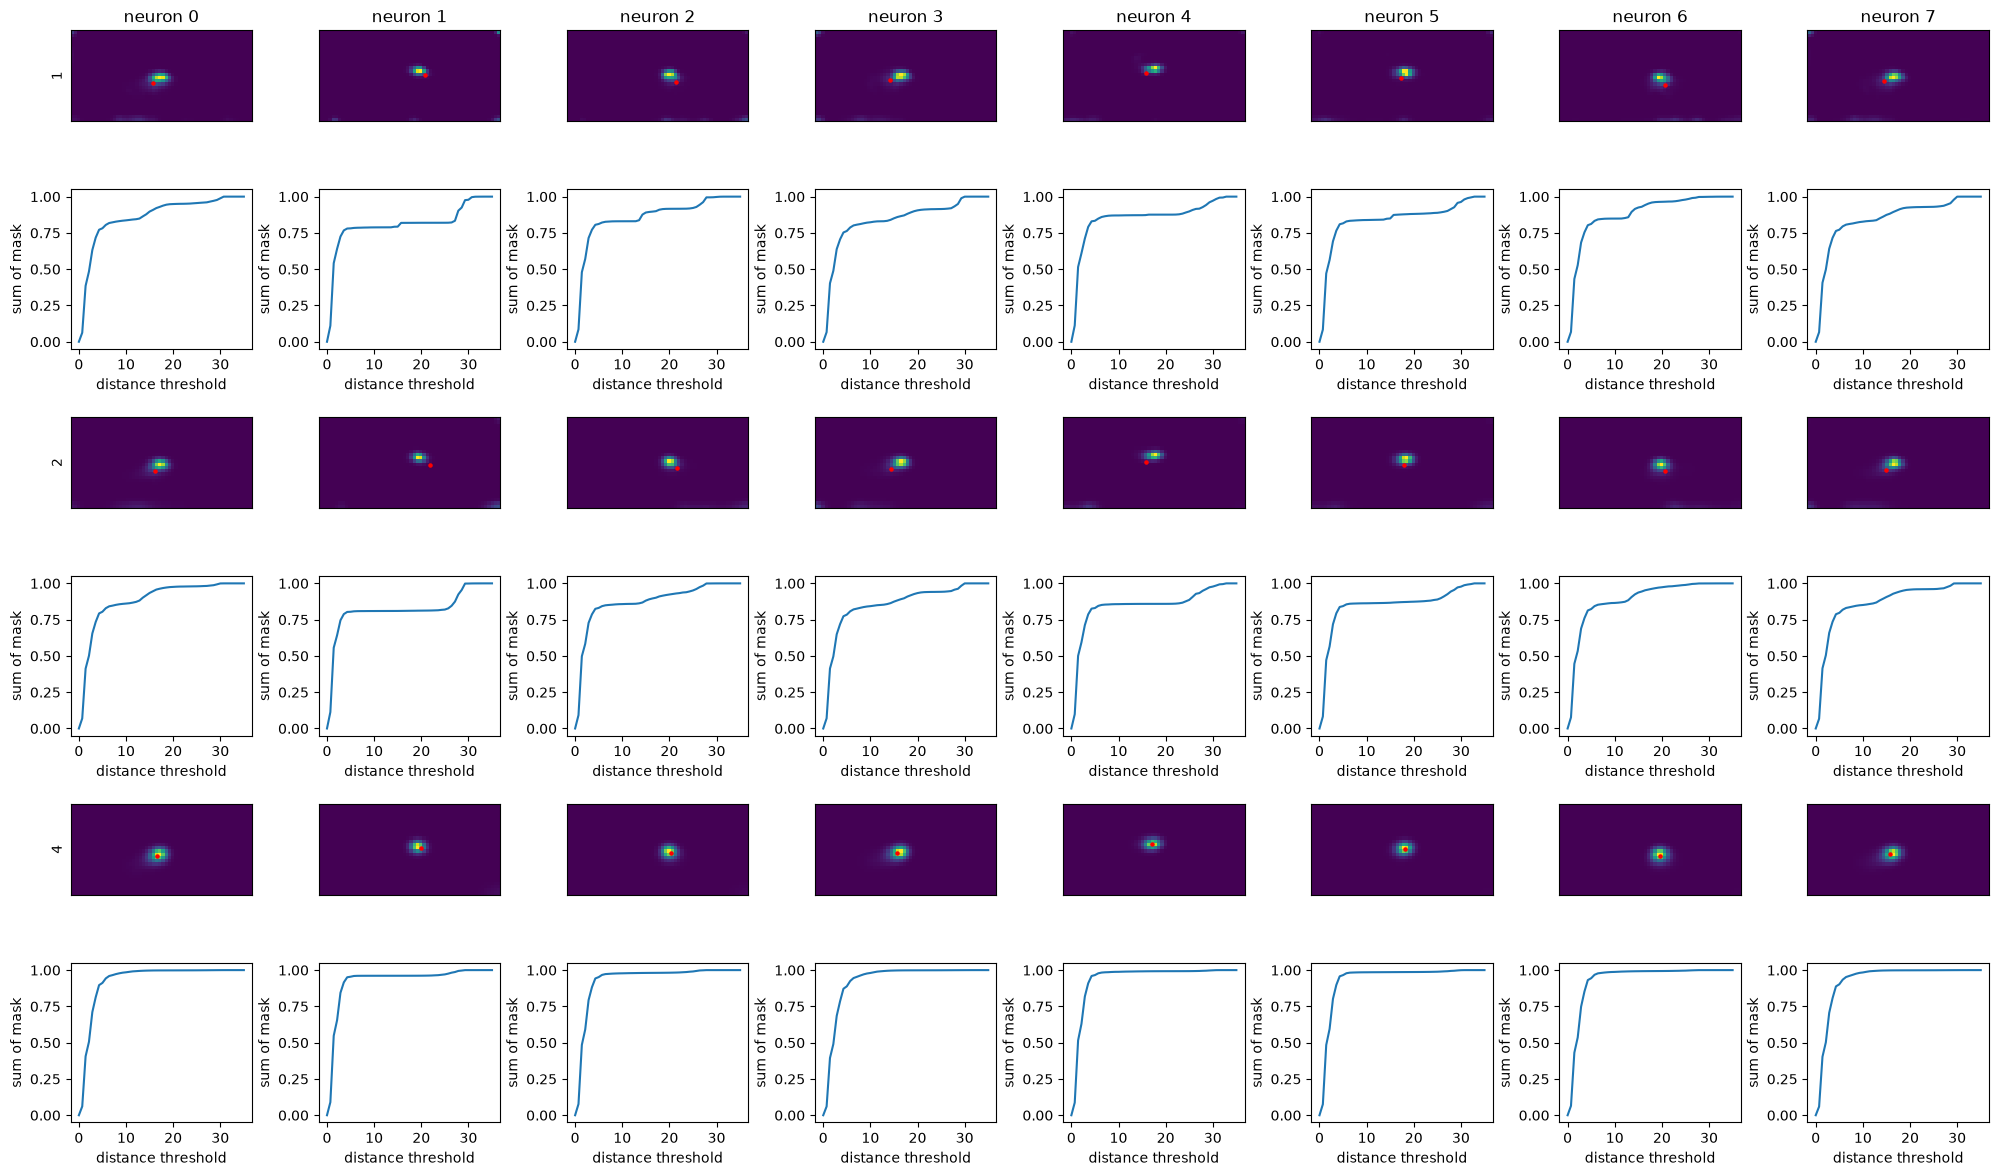

In [4]:
n = 8
fig, axs = plt.subplots(len(models) * 2, n, figsize=(20, 12))
neurons = None

for i, (sigma, sigma_models) in enumerate(models.items()):    
    model = sigma_models[0]
    spatials = torch.cat([model.readout[k].spatial.detach().cpu() for k in [data_keys[6]]])
    neurons = torch.randperm(spatials.shape[0])[:n] if neurons is None else neurons
    for j in range(n):
        ax = axs[i * 2][j]
        spatial = spatials[neurons[j]]

        h, w = spatial.shape
        y = spatial.sum(dim=1)  # h
        x = spatial.sum(dim=0)  # w

        y_pos = torch.arange(h)
        x_pos = torch.arange(w)

        y_avg = (y_pos * y).sum()
        x_avg = (x_pos * x).sum()

        ax.imshow(spatial)
        ax.scatter(x_avg, y_avg, s=5, color='red')
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 0:
            ax.set_title(f'neuron {j}')
        if j == 0:
            ax.set_ylabel(sigma)

        y_max = y.argmax()
        x_max = x.argmax()

        y_dist = (y_pos - y_max).pow(2)
        x_dist = (x_pos - x_max).pow(2)

        yy, xx = torch.meshgrid(y_dist, x_dist, indexing='ij')
        dists = torch.stack([xx, yy], dim=-1).sum(-1).sqrt()

        thresholds = torch.linspace(0, 35, steps=50)
        volumes = []
        for t in thresholds:
            vol = spatial[dists < t].sum()
            volumes.append(vol)
        
        ax = axs[i * 2 + 1][j]
        ax.plot(thresholds, volumes)
        ax.set_xlabel('distance threshold')
        ax.set_ylabel('sum of mask')

plt.tight_layout()

In [4]:
full_grids = {}
for sigma, sigma_models in models.items():
    sigma_grids = []
    for model in sigma_models:
        grids = []
        for key in data_keys:
            spatial = model.readout[key].spatial.detach().cpu()
            n, h, w = spatial.shape
            y = spatial.sum(dim=2)  # n, h
            x = spatial.sum(dim=1)  # n, w

            y_pos = torch.arange(h).unsqueeze(0).expand(n, h)
            x_pos = torch.arange(w).unsqueeze(0).expand(n, w)

            y_avg = (y_pos * y).sum(dim=1)
            x_avg = (x_pos * x).sum(dim=1)
            
            grid = torch.stack([x_avg, y_avg], dim=1)
            grids.append(grid)
        sigma_grids.append(grids)

    full_grids[sigma] = sigma_grids

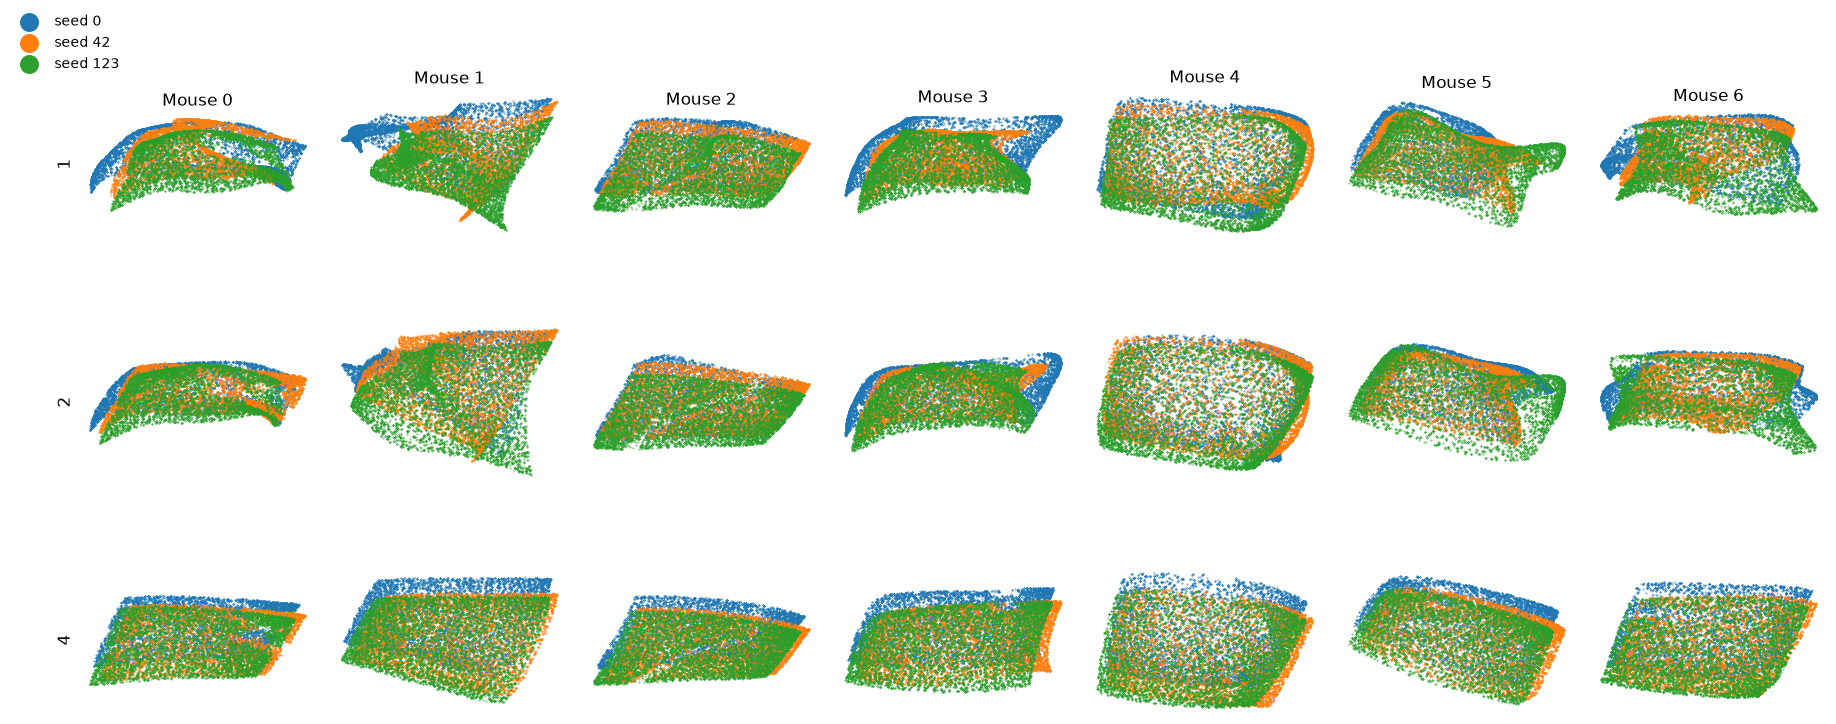

In [5]:
model_seeds = [0, 42, 123]
model_types = full_grids

num_mice = 7
num_models = len(model_seeds)

fig, axs = plt.subplots(len(model_types), num_mice, figsize=(18, 8))

for row_idx, (type_name, grids) in enumerate(full_grids.items()):
    for mouse_idx in range(num_mice):
        ax = axs[row_idx, mouse_idx]
        for model_idx in range(num_models):
            grid = grids[model_idx][mouse_idx]
            ax.scatter(
                grid[:, 0], grid[:, 1],
                alpha=1, s=0.1,
                label=f"seed {model_seeds[model_idx]}",
            )
        ax.set_aspect('equal')

        # remove spines and ticks
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])

        # column labels on top row only
        if row_idx == 0:
            ax.set_title(f"Mouse {mouse_idx}")

        # row labels on first column only
        if mouse_idx == 0:
            ax.set_ylabel(type_name, rotation=90, size='large')

# single shared legend for seeds (bigger markers than the tiny scatter points)
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    bbox_to_anchor=(0.05, 1.0),
    markerscale=40,
    frameon=False,
)

plt.tight_layout()
plt.show()

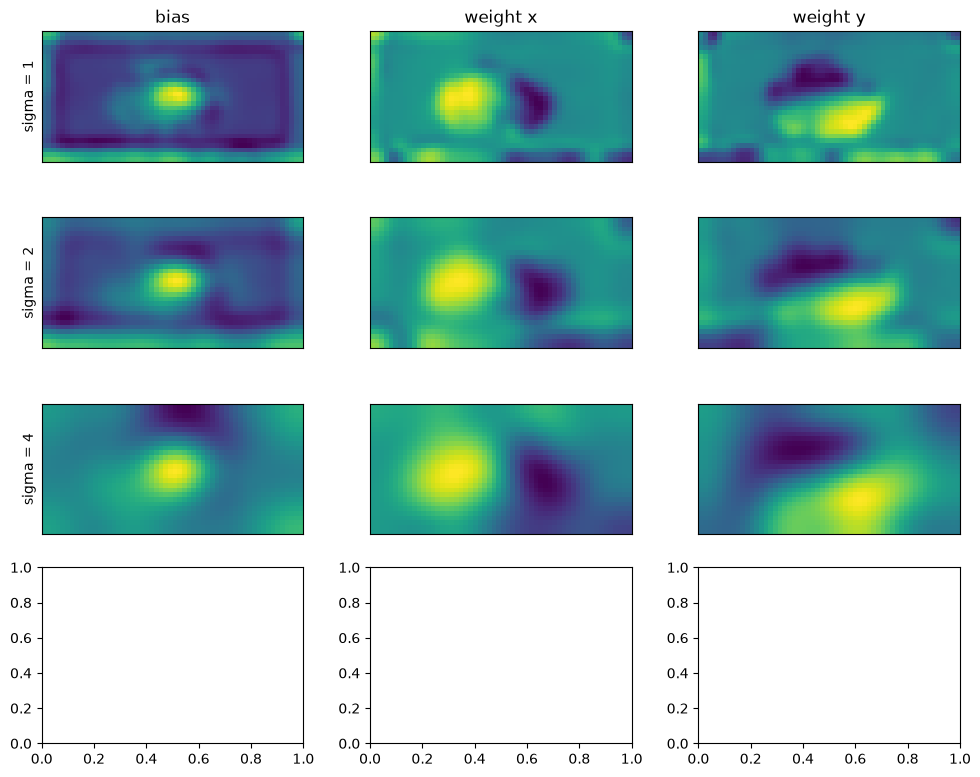

In [10]:
fig, axs = plt.subplots(4, 3, figsize=(10, 8))
for i, (sigma, model) in enumerate(models.items()):
    readout = model[0].readout[data_keys[6]]
    kernel = readout.gaussian_kernel('cpu')
    bias = readout.smooth(readout.spatial_b, kernel).detach().to('cpu')
    weight = readout.smooth(readout.spatial_w, kernel).detach().to('cpu')
    # bias = readout.spatial_b.detach().cpu()
    # weight = readout.spatial_w.detach().cpu()
    
    axs[i][0].imshow(bias[0])
    axs[i][0].set_xticks([])
    axs[i][0].set_yticks([])
    axs[i][0].set_ylabel(f'sigma = {sigma}')

    axs[i][1].imshow(weight[1])
    axs[i][1].set_xticks([])
    axs[i][1].set_yticks([])
    
    axs[i][2].imshow(weight[0])
    axs[i][2].set_xticks([])
    axs[i][2].set_yticks([])

    if i == 0:
        axs[i][0].set_title(f'bias')
        axs[i][1].set_title(f'weight x')
        axs[i][2].set_title(f'weight y')

plt.tight_layout()
plt.show()

# knn

In [11]:
curves = {}
for sigma, sigma_models in models.items():
    readouts = []
    for model in sigma_models:
        r = torch.cat([model.readout[key].features.detach() for key in data_keys])
        r = model.whitener.transform_weights(r.T).T.cpu()
        readouts.append(r)

    curve, k_range = get_knn_curve(readouts)
    curves[sigma] = curve

cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7
cuda:7


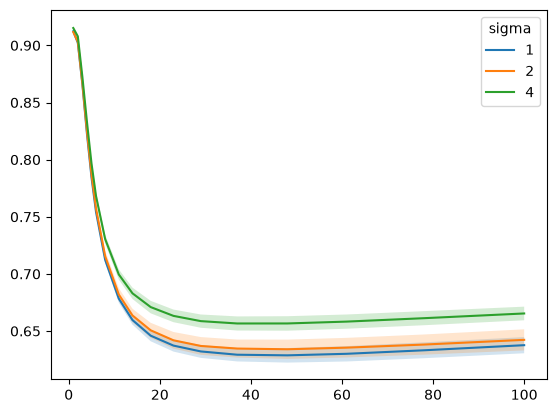

In [12]:
for sigma, curve in curves.items():
    m, s = curve[0], curve[1]
    plt.plot(k_range, m, label=sigma)
    plt.fill_between(k_range, m - s, m + s, alpha=0.2)

plt.legend(title='sigma')
plt.show()

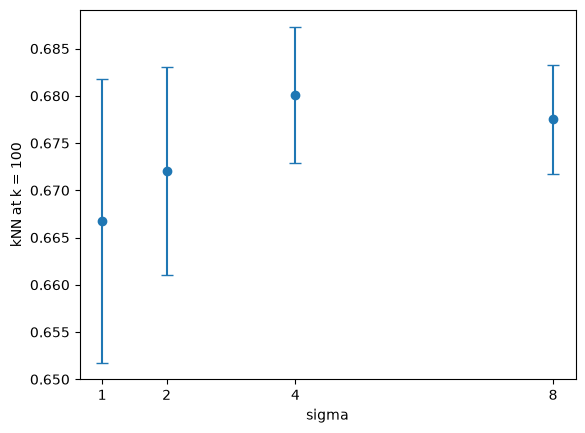

In [13]:
sigmas = sorted(curves.keys())
finals = [curves[s][0][-1] for s in sigmas]  # final mean
stds = [curves[s][1][-1] for s in sigmas]    # final std

plt.errorbar(sigmas, finals, yerr=stds, fmt='o', capsize=4)
plt.xticks(sigmas)
plt.xlabel('sigma')
plt.ylabel('kNN at k = 100')
plt.show()

In [14]:
paths = {
    0.5:[
        '../training/runs/sigma4/sigma4_seed0',
        '../training/runs/sigma4/sigma4_seed42',
        '../training/runs/sigma4/sigma4_seed123',
    ],
    1.0: [
        '../training/runs/sigma4/sigma4_size17_seed0',
        '../training/runs/sigma4/sigma4_size17_seed42',
        '../training/runs/sigma4/sigma4_size17_seed123',
    ],
}

models = {}
for temp, sigma_paths in paths.items():
    temp_models = []
    for path in sigma_paths:
        model = load_model_from_config(path, dataloaders, device)
        temp_models.append(model)
    models[temp] = temp_models

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [15]:
curves = {}
for sigma, sigma_models in models.items():
    readouts = []
    for model in sigma_models:
        r = torch.cat([model.readout[key].features.detach() for key in data_keys])
        r = model.whitener.transform_weights(r.T).T.cpu()
        readouts.append(r)

    curve, k_range = get_knn_curve(readouts)
    curves[sigma] = curve

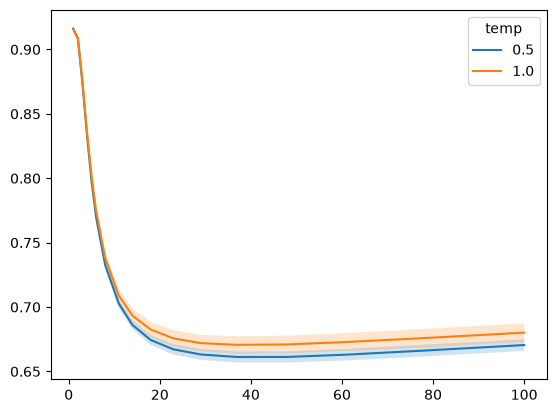

In [16]:
for temp, curve in curves.items():
    m, s = curve[0], curve[1]
    plt.plot(k_range, m, label=temp)
    plt.fill_between(k_range, m - s, m + s, alpha=0.2)

plt.legend(title='temp')
plt.show()

In [2]:
def gaussian_kernel(size, sigma):
    x = torch.arange(size) - size // 2
    xx, yy = torch.meshgrid(x, x, indexing="ij")
    kernel = torch.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel = kernel / kernel.sum()
    return kernel.view(1, 1, size, size)

In [ ]:
5: 1
9: 2
17: 4
33: 8

tensor([[0.0113, 0.0838, 0.0113],
        [0.0838, 0.6193, 0.0838],
        [0.0113, 0.0838, 0.0113]])


(0.0, 0.6461233504116535)

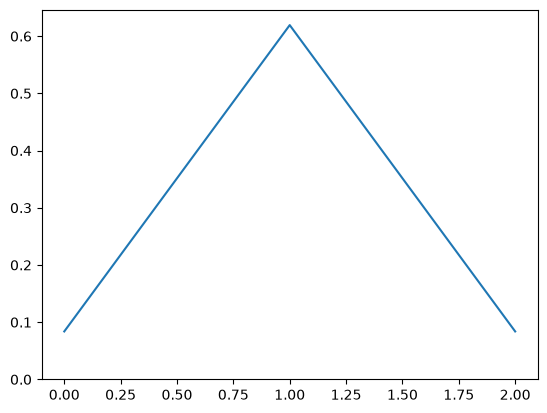

In [11]:
kernel = gaussian_kernel(3, 0.5)[0, 0]
print(kernel)
plt.plot(kernel[kernel.shape[0] // 2])
plt.ylim(0)
# plt.imshow(kernel, vmin=0)

In [105]:
1e-2

0.01

In [118]:
from sensorium.models import stacked_core_factorized_readout

model_config = {
    'hidden_channels': 96, # original sensorium was 64ch
    'depth_separable': False,
    'use_avg_reg': False,
    'laplace_padding': None,
    'momentum': 0.75,
    'final_nonlinearity': True,
    'nonlinearity_type': 'AdaptiveELU',
    'pad_input': False,
    'hidden_padding': None, 
    'stack': -1,
    'layers': 4,
    'input_kern': 9, #  original sensorium was 'input_kern': 9,
    'gamma_input': 6.3831, # this should not influence the performance based on previous experience
    
    'feature_reg_weight': 1.0, # this is the one I actually would like to tune!
    
    'hidden_kern': 7,
    
    'shifter': True,
    'shifter_bias': False,
    'hidden_channels_shifter': 5,
    'shift_layers': 1,
    'batch_norm_scale': [True, True, True, False],
    'core_bias': [True, True, True, False],
    'regularizer_type': 'adaptive_log_norm',
    'gamma_sigma': 0.25,
    'init_gain': 0.1,
    'whitener': True,
    'whitener_momentum': 0.003,
}

model_config['spatial_init_noise'] = 0.04
model_config['temperature'] = 0.2
model_config['temp_per_neuron'] = False
model_config['readout_kernel_size'] = 17
model_config['readout_kernel_sigma'] = 4.0
model_config['smoothness_reg_weight'] = 0.0
model_config['entropy_reg_weight'] = 0.0
model = stacked_core_factorized_readout(dataloaders, random_seed, **model_config)

print(model)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


FiringRateEncoder(
  (core): Stacked2dCore(
    (_input_weights_regularizer): LaplaceL2norm(
      (laplace): Laplace()
    )
    (features): Sequential(
      (layer0): Sequential(
        (conv): Conv2d(4, 96, kernel_size=(9, 9), stride=(1, 1), bias=False)
        (norm): BatchNorm2d(96, eps=1e-05, momentum=0.75, affine=True, bias=True, track_running_stats=False)
        (nonlin): AdaptiveELU()
      )
      (layer1): Sequential(
        (conv): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
        (norm): BatchNorm2d(96, eps=1e-05, momentum=0.75, affine=True, bias=True, track_running_stats=False)
        (nonlin): AdaptiveELU()
      )
      (layer2): Sequential(
        (conv): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
        (norm): BatchNorm2d(96, eps=1e-05, momentum=0.75, affine=True, bias=True, track_running_stats=False)
        (nonlin): AdaptiveELU()
      )
      (layer3): Sequential(
        (conv): Conv2d(96, 96, kernel_size=(7,

In [119]:
spatial = model.readout[data_keys[0]].spatial.detach().cpu()

In [120]:
spatial.max(), spatial.min()

(tensor(0.0007), tensor(0.0006))

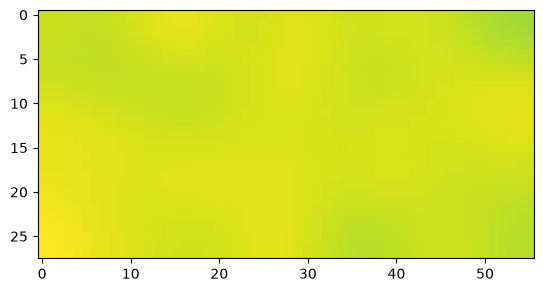

In [121]:
plt.imshow(spatial[10], vmin=0)